In [1]:
# ==========================================================
# Imports
# ==========================================================

from pathlib import Path

import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

DATASET_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset.npz"
)

sensor_data = np.load(DATASET_PATH)

X = sensor_data["X"]
y = sensor_data["y"]
groups = sensor_data["groups"]

print(X.shape)

(30676, 120, 13)


In [5]:
unique_groups = np.unique(groups)

trip_labels = np.array([
    y[groups == trip][0]
    for trip in unique_groups
])

train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.20,
    random_state=42,
    stratify=trip_labels,
)

In [6]:
train_mask = np.isin(
    groups,
    train_groups,
)

test_mask = np.isin(
    groups,
    test_groups,
)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [7]:
print(X_train.shape)
print(X_test.shape)

(24725, 120, 13)
(5951, 120, 13)


In [8]:
import torch
from torch.utils.data import Dataset


class SensorDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [9]:
train_dataset = SensorDataset(
    X_train,
    y_train,
)

test_dataset = SensorDataset(
    X_test,
    y_test,
)

print(len(train_dataset))
print(len(test_dataset))

24725
5951


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

773
186


In [11]:
sensor, label = next(iter(train_loader))

print(sensor.shape)
print(label.shape)

torch.Size([32, 120, 13])
torch.Size([32])


In [12]:
import sys

SRC = "/content/drive/MyDrive/UAH_Project/src"

if SRC not in sys.path:
    sys.path.insert(0, SRC)

In [13]:
import lstm_model

print(dir(lstm_model))

['LSTMClassifier', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'nn', 'torch']


In [14]:
import importlib

import lstm_model
import trainer

importlib.reload(lstm_model)
importlib.reload(trainer)

from lstm_model import LSTMClassifier
from trainer import fit

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [16]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

weights = torch.FloatTensor(
    class_weights
).to(device)

print(class_weights)

[0.82121031 0.98690776 1.30035763]


In [17]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [19]:
EPOCHS = 20
PATIENCE = 3

In [20]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 1.0160 | Train Acc: 0.4623 | Val Loss: 1.0761 | Val Acc: 0.4453
Epoch 2/20 | Train Loss: 0.8608 | Train Acc: 0.6021 | Val Loss: 0.9528 | Val Acc: 0.5171
Epoch 3/20 | Train Loss: 0.7917 | Train Acc: 0.6370 | Val Loss: 0.9851 | Val Acc: 0.5071
Epoch 4/20 | Train Loss: 0.7582 | Train Acc: 0.6530 | Val Loss: 0.9360 | Val Acc: 0.5124
Epoch 5/20 | Train Loss: 0.7273 | Train Acc: 0.6736 | Val Loss: 0.9891 | Val Acc: 0.4949

Early stopping at epoch 5
Best Validation Accuracy : 0.5171


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor, labels in test_loader:

        sensor = sensor.to(device)

        outputs = model(sensor)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [22]:
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")

Accuracy : 0.5171
Precision: 0.5643
Recall   : 0.5171
F1 Score : 0.5143


In [23]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.61      0.35      0.45      2955
      DROWSY       0.34      0.59      0.43      1495
  AGGRESSIVE       0.69      0.77      0.73      1501

    accuracy                           0.52      5951
   macro avg       0.55      0.57      0.54      5951
weighted avg       0.56      0.52      0.51      5951



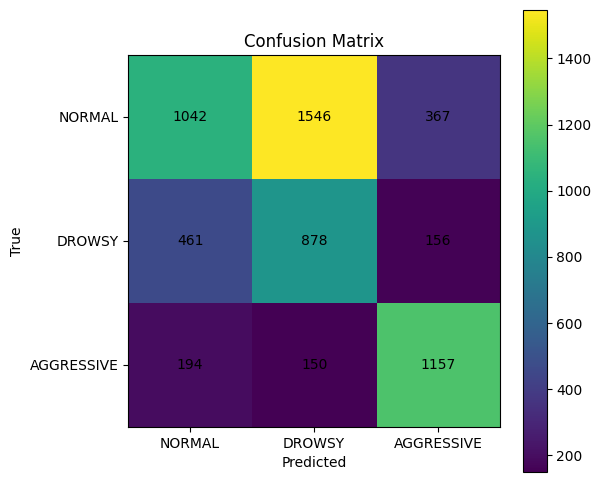

In [24]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()

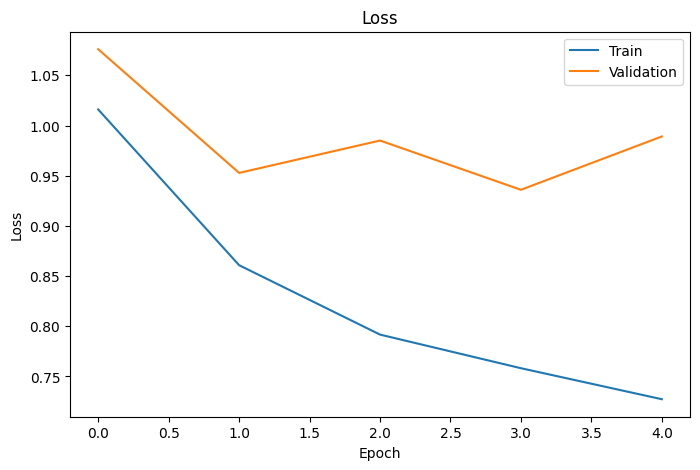

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss")

plt.legend()

plt.show()

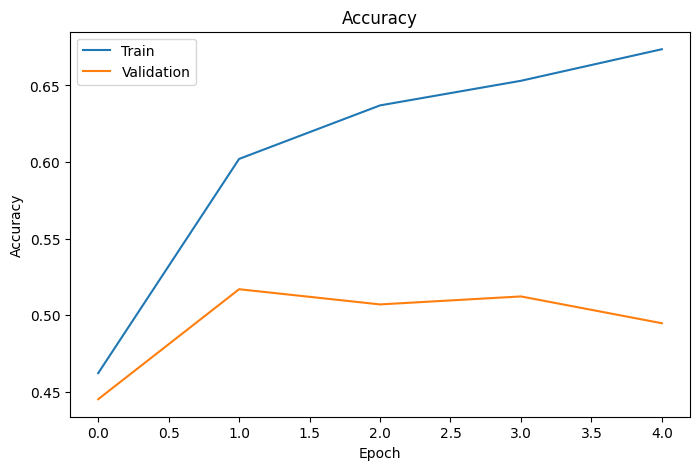

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy")

plt.legend()

plt.show()

# ====================================================
# Experiment 1 - StandardScaler + Gradient Clipping
# ====================================================

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_shape = X_train.shape
test_shape = X_test.shape

X_train_flat = X_train.reshape(-1, train_shape[-1])
X_test_flat = X_test.reshape(-1, test_shape[-1])

X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

X_train = X_train_scaled.reshape(train_shape)
X_test = X_test_scaled.reshape(test_shape)

print(X_train.shape)
print(X_test.shape)

(24725, 120, 13)
(5951, 120, 13)


In [30]:
train_dataset = SensorDataset(
    X_train,
    y_train,
)

test_dataset = SensorDataset(
    X_test,
    y_test,
)
print(len(train_dataset))
print(len(test_dataset))

24725
5951


In [31]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

In [32]:
model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [33]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

weights = torch.FloatTensor(
    class_weights
).to(device)

In [34]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [35]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [36]:
EPOCHS = 20
PATIENCE = 3

In [37]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 0.9494 | Train Acc: 0.5022 | Val Loss: 0.8649 | Val Acc: 0.5003
Epoch 2/20 | Train Loss: 0.7116 | Train Acc: 0.6571 | Val Loss: 0.8098 | Val Acc: 0.5703
Epoch 3/20 | Train Loss: 0.6232 | Train Acc: 0.7210 | Val Loss: 0.7673 | Val Acc: 0.6727
Epoch 4/20 | Train Loss: 0.5903 | Train Acc: 0.7431 | Val Loss: 0.7664 | Val Acc: 0.6910
Epoch 5/20 | Train Loss: 0.5631 | Train Acc: 0.7603 | Val Loss: 0.8376 | Val Acc: 0.6607
Epoch 6/20 | Train Loss: 0.5440 | Train Acc: 0.7704 | Val Loss: 0.8399 | Val Acc: 0.6594
Epoch 7/20 | Train Loss: 0.5272 | Train Acc: 0.7777 | Val Loss: 0.8463 | Val Acc: 0.6562

Early stopping at epoch 7
Best Validation Accuracy : 0.6910


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor, labels in test_loader:

        sensor = sensor.to(device)

        outputs = model(sensor)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [40]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.71      0.70      0.70      2955
      DROWSY       0.58      0.47      0.52      1495
  AGGRESSIVE       0.74      0.89      0.81      1501

    accuracy                           0.69      5951
   macro avg       0.68      0.69      0.68      5951
weighted avg       0.68      0.69      0.68      5951



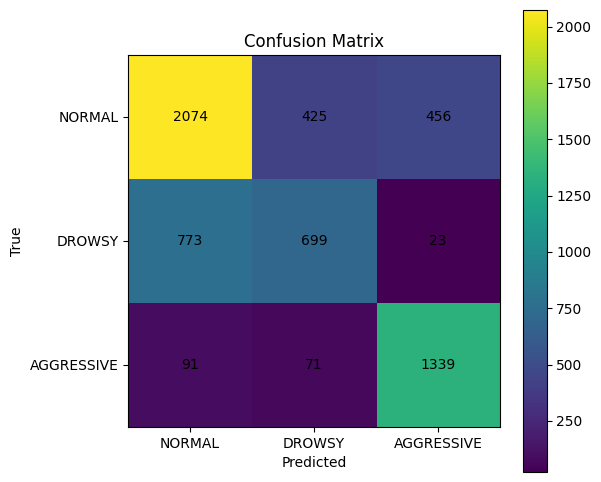

In [41]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()

In [44]:
train_dataset = SensorDataset(
    X_train,
    y_train,
)

test_dataset = SensorDataset(
    X_test,
    y_test,
)

print(len(train_dataset))
print(len(test_dataset))

24725
5951


In [45]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

773
186


In [46]:
model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [47]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [48]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [49]:
EPOCHS = 20
PATIENCE = 3

In [51]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 0.9283 | Train Acc: 0.4967 | Val Loss: 0.8731 | Val Acc: 0.4848
Epoch 2/20 | Train Loss: 0.7188 | Train Acc: 0.6633 | Val Loss: 0.8224 | Val Acc: 0.5567
Epoch 3/20 | Train Loss: 0.6335 | Train Acc: 0.7211 | Val Loss: 0.8518 | Val Acc: 0.5816
Epoch 4/20 | Train Loss: 0.5993 | Train Acc: 0.7352 | Val Loss: 0.7542 | Val Acc: 0.6525
Epoch 5/20 | Train Loss: 0.5689 | Train Acc: 0.7490 | Val Loss: 0.7987 | Val Acc: 0.6569
Epoch 6/20 | Train Loss: 0.5459 | Train Acc: 0.7625 | Val Loss: 0.8059 | Val Acc: 0.6552
Epoch 7/20 | Train Loss: 0.5229 | Train Acc: 0.7727 | Val Loss: 0.7722 | Val Acc: 0.6648
Epoch 8/20 | Train Loss: 0.4989 | Train Acc: 0.7853 | Val Loss: 0.7863 | Val Acc: 0.6970
Epoch 9/20 | Train Loss: 0.4756 | Train Acc: 0.7933 | Val Loss: 0.7575 | Val Acc: 0.6979
Epoch 10/20 | Train Loss: 0.4507 | Train Acc: 0.8036 | Val Loss: 0.7963 | Val Acc: 0.6769
Epoch 11/20 | Train Loss: 0.4206 | Train Acc: 0.8188 | Val Loss: 0.8415 | Val Acc: 0.6794
Epoch 12/20 | Train

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor, labels in test_loader:

        sensor = sensor.to(device)

        outputs = model(sensor)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [54]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.77      0.61      0.68      2955
      DROWSY       0.54      0.70      0.61      1495
  AGGRESSIVE       0.77      0.88      0.82      1501

    accuracy                           0.70      5951
   macro avg       0.70      0.73      0.70      5951
weighted avg       0.71      0.70      0.70      5951



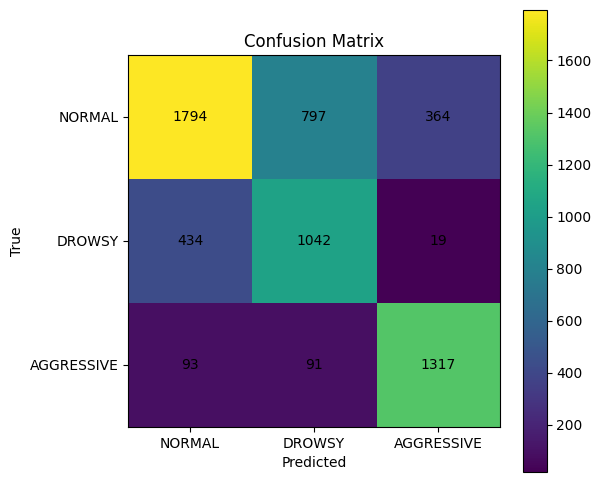

In [55]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()

==========================================================

Experiment 2 - Without Gradient Clipping

==========================================================

In [56]:
import trainer

importlib.reload(trainer)

from trainer import fit

In [57]:
train_dataset = SensorDataset(
    X_train,
    y_train,
)

test_dataset = SensorDataset(
    X_test,
    y_test,
)

print(len(train_dataset))
print(len(test_dataset))

24725
5951


In [58]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

773
186


In [59]:
model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [60]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [61]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [62]:
EPOCHS = 20
PATIENCE = 3

In [63]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 0.9514 | Train Acc: 0.4944 | Val Loss: 0.9464 | Val Acc: 0.4966
Epoch 2/20 | Train Loss: 0.7746 | Train Acc: 0.6161 | Val Loss: 0.8271 | Val Acc: 0.5124
Epoch 3/20 | Train Loss: 0.7060 | Train Acc: 0.6483 | Val Loss: 0.8399 | Val Acc: 0.5179
Epoch 4/20 | Train Loss: 0.6646 | Train Acc: 0.6685 | Val Loss: 0.8430 | Val Acc: 0.5339
Epoch 5/20 | Train Loss: 0.6276 | Train Acc: 0.6792 | Val Loss: 0.7921 | Val Acc: 0.5628
Epoch 6/20 | Train Loss: 0.5971 | Train Acc: 0.6917 | Val Loss: 0.7941 | Val Acc: 0.5564
Epoch 7/20 | Train Loss: 0.5726 | Train Acc: 0.7060 | Val Loss: 0.9050 | Val Acc: 0.5646
Epoch 8/20 | Train Loss: 0.5864 | Train Acc: 0.7007 | Val Loss: 0.8768 | Val Acc: 0.5697
Epoch 9/20 | Train Loss: 0.6089 | Train Acc: 0.7152 | Val Loss: 0.8147 | Val Acc: 0.6033
Epoch 10/20 | Train Loss: 0.5583 | Train Acc: 0.7266 | Val Loss: 0.7465 | Val Acc: 0.5777
Epoch 11/20 | Train Loss: 0.5329 | Train Acc: 0.7291 | Val Loss: 0.7302 | Val Acc: 0.5991
Epoch 12/20 | Train

==========================================================

Experiment 3 - Hidden Size = 128 + Standart Scaler + Gradient Boosting

==========================================================

In [77]:
import importlib

import lstm_model
import trainer

importlib.reload(lstm_model)
importlib.reload(trainer)

from lstm_model import LSTMClassifier
from trainer import fit

In [78]:
train_dataset = SensorDataset(
    X_train,
    y_train,
)

test_dataset = SensorDataset(
    X_test,
    y_test,
)

print(len(train_dataset))
print(len(test_dataset))

24725
5951


In [79]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

773
186


In [80]:
model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [81]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [82]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [83]:
EPOCHS = 20
PATIENCE = 3

In [84]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 0.8777 | Train Acc: 0.5225 | Val Loss: 0.8947 | Val Acc: 0.5159
Epoch 2/20 | Train Loss: 0.6768 | Train Acc: 0.6784 | Val Loss: 0.8328 | Val Acc: 0.6222
Epoch 3/20 | Train Loss: 0.6053 | Train Acc: 0.7240 | Val Loss: 0.7240 | Val Acc: 0.6969
Epoch 4/20 | Train Loss: 0.5676 | Train Acc: 0.7495 | Val Loss: 0.7868 | Val Acc: 0.6873
Epoch 5/20 | Train Loss: 0.5328 | Train Acc: 0.7610 | Val Loss: 0.7986 | Val Acc: 0.6801
Epoch 6/20 | Train Loss: 0.4967 | Train Acc: 0.7844 | Val Loss: 0.7888 | Val Acc: 0.6969

Early stopping at epoch 6
Best Validation Accuracy : 0.6969


In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor, labels in test_loader:

        sensor = sensor.to(device)

        outputs = model(sensor)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [86]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.72      0.69      0.70      2955
      DROWSY       0.56      0.53      0.54      1495
  AGGRESSIVE       0.77      0.88      0.82      1501

    accuracy                           0.70      5951
   macro avg       0.68      0.70      0.69      5951
weighted avg       0.69      0.70      0.69      5951



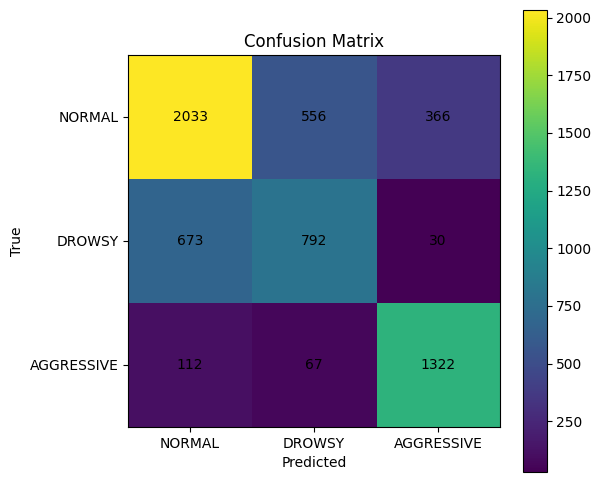

In [87]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()

==========================================================

Experiment 4 - AdamW + Weight Decay

==========================================================

In [88]:
import importlib

import lstm_model
import trainer

importlib.reload(lstm_model)
importlib.reload(trainer)

from lstm_model import LSTMClassifier
from trainer import fit

In [89]:
train_dataset = SensorDataset(
    X_train,
    y_train,
)

test_dataset = SensorDataset(
    X_test,
    y_test,
)

print(len(train_dataset))
print(len(test_dataset))

24725
5951


In [90]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

773
186


In [91]:
model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [92]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [93]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

In [94]:
EPOCHS = 20
PATIENCE = 3

In [95]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 0.9262 | Train Acc: 0.5208 | Val Loss: 0.8456 | Val Acc: 0.5396
Epoch 2/20 | Train Loss: 0.7027 | Train Acc: 0.6601 | Val Loss: 0.8350 | Val Acc: 0.5740
Epoch 3/20 | Train Loss: 0.6321 | Train Acc: 0.6886 | Val Loss: 0.7925 | Val Acc: 0.5643
Epoch 4/20 | Train Loss: 0.5851 | Train Acc: 0.7117 | Val Loss: 0.7468 | Val Acc: 0.5760
Epoch 5/20 | Train Loss: 0.5365 | Train Acc: 0.7411 | Val Loss: 0.7452 | Val Acc: 0.6056
Epoch 6/20 | Train Loss: 0.5080 | Train Acc: 0.7619 | Val Loss: 0.7387 | Val Acc: 0.6801
Epoch 7/20 | Train Loss: 0.4845 | Train Acc: 0.7799 | Val Loss: 0.7871 | Val Acc: 0.6261
Epoch 8/20 | Train Loss: 0.4617 | Train Acc: 0.7907 | Val Loss: 0.8705 | Val Acc: 0.5723
Epoch 9/20 | Train Loss: 0.4341 | Train Acc: 0.8061 | Val Loss: 0.7337 | Val Acc: 0.6947
Epoch 10/20 | Train Loss: 0.4166 | Train Acc: 0.8222 | Val Loss: 0.9453 | Val Acc: 0.5996
Epoch 11/20 | Train Loss: 0.3900 | Train Acc: 0.8345 | Val Loss: 1.0451 | Val Acc: 0.6091
Epoch 12/20 | Train

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor, labels in test_loader:

        sensor = sensor.to(device)

        outputs = model(sensor)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [97]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.74      0.66      0.70      2955
      DROWSY       0.52      0.62      0.56      1495
  AGGRESSIVE       0.82      0.85      0.83      1501

    accuracy                           0.69      5951
   macro avg       0.69      0.71      0.70      5951
weighted avg       0.70      0.69      0.70      5951



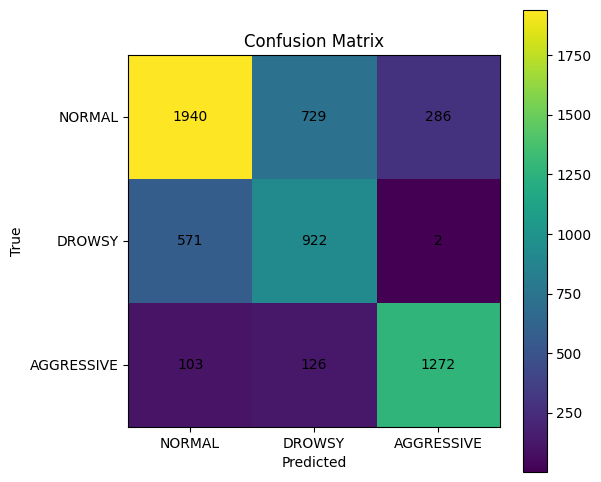

In [98]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()